Loaded: Alibaba.csv
Loaded: Aliexpress.csv
Loaded: Amazon shopping.csv
Loaded: Daraz Online Shopping App.csv
Loaded: eBay online shopping & selling.csv
Loaded: Flipkart.csv
Loaded: Lazada.csv
Loaded: Meesho.csv
Loaded: Myntra.csv
Loaded: Shein.csv
Loaded: Snapdeal.csv
Loaded: Walmart.csv

--- Applying App-Balanced Sampling (12 Apps) ---
Total balanced records: 119,762
Cleaning text and linking negations...


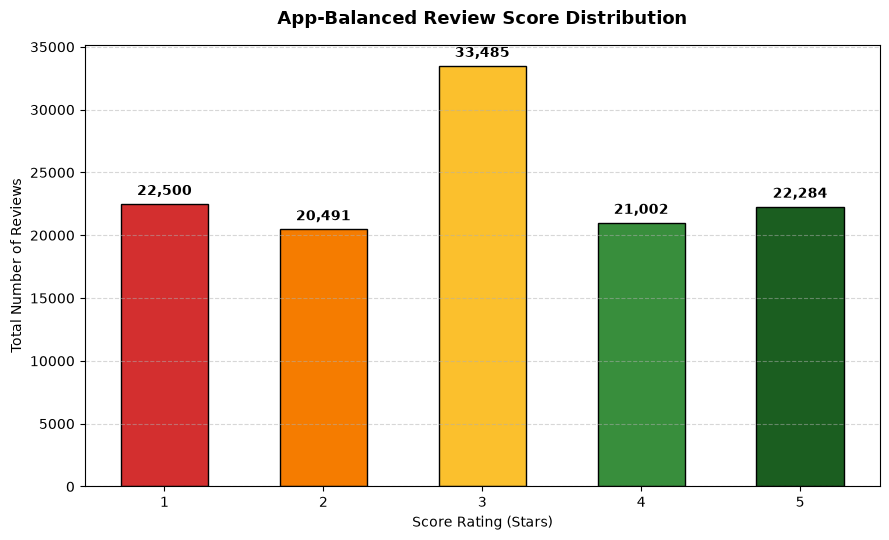

In [33]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import re

# 1. Target files
data_dir = Path("data")
target_files = [
    data_dir / "Alibaba.csv", data_dir / "Aliexpress.csv", data_dir / "Amazon shopping.csv",
    data_dir / "Daraz Online Shopping App.csv", data_dir / "eBay online shopping & selling.csv",
    data_dir / "Flipkart.csv", data_dir / "Lazada.csv", data_dir / "Meesho.csv",
    data_dir / "Myntra.csv", data_dir / "Shein.csv", data_dir / "Snapdeal.csv", data_dir / "Walmart.csv"
]

# 2. Load and track source
df_list = []
for file_path in target_files:
    if file_path.exists():
        try:
            temp_df = pd.read_csv(file_path)
            temp_df['appName'] = file_path.stem
            df_list.append(temp_df)
            print(f"Loaded: {file_path.name}")
        except Exception as e:
            print(f"Error reading {file_path.name}: {e}")

if df_list:
    combined_df = pd.concat(df_list, ignore_index=True)
    combined_df['score'] = pd.to_numeric(combined_df['score'], errors='coerce')
    combined_df = combined_df.dropna(subset=['score'])
    combined_df['score'] = combined_df['score'].astype(int)
    
    # 3. App-Stratified Sparse Sampling
    target_samples = {1: 22500, 2: 22500, 3: 45000, 4: 22500, 5: 22500}
    unique_apps = combined_df['appName'].unique()
    num_apps = len(unique_apps)
    sampled_dfs = []
    
    print(f"\n--- Applying App-Balanced Sampling ({num_apps} Apps) ---")
    for score, total_target in target_samples.items():
        target_per_app = int(total_target / num_apps)
        for app in unique_apps:
            subset = combined_df[(combined_df['score'] == score) & (combined_df['appName'] == app)]
            if len(subset) >= target_per_app:
                sampled_dfs.append(subset.sample(n=target_per_app, random_state=42))
            else:
                sampled_dfs.append(subset)
                
    balanced_df = pd.concat(sampled_dfs, ignore_index=True)
    print(f"Total balanced records: {len(balanced_df):,}")
    
    # 4. Sentiment Mapping
    sentiment_mapping = {5: 'positive', 4: 'positive', 3: 'medium', 2: 'negative', 1: 'negative'}
    balanced_df['sentiment'] = balanced_df['score'].map(sentiment_mapping)
    
    # 5. Text Preprocessing (Negation Fix)
    print("Cleaning text and linking negations...")
    def handle_negations(text):
        if not isinstance(text, str): return ""
        text = text.lower()
        neg_pattern = r"\b(not|no|never|isn't|aren't|wasn't|weren't|haven't|hasn't|hadn't|won't|wouldn't|don't|doesn't|didn't|can't|couldn't|shouldn't|mightn't|mustn't)\s+(\w+)"
        text = re.sub(neg_pattern, r"not_\2", text)
        text = re.sub(r"[^\w\s_]", " ", text)
        return re.sub(r"\s+", " ", text).strip()

    balanced_df['clean_content'] = balanced_df['content'].apply(handle_negations)
    
    # Save Output
    output_path = data_dir / "balanced_shopping_reviews.csv"
    balanced_df.to_csv(output_path, index=False)
    
    # 6. Plot Score Distribution
    score_counts = balanced_df['score'].value_counts()
    all_possible_scores = pd.Series(0, index=[1, 2, 3, 4, 5])
    total_distribution = all_possible_scores.add(score_counts, fill_value=0).astype(int)
    
    plt.figure(figsize=(9, 5.5))
    colors = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c', '#1b5e20']
    bars = plt.bar(total_distribution.index, total_distribution.values, color=colors, edgecolor='black', width=0.55)
    
    plt.title('App-Balanced Review Score Distribution', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Score Rating (Stars)')
    plt.ylabel('Total Number of Reviews')
    plt.xticks([1, 2, 3, 4, 5])
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:,}', xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()

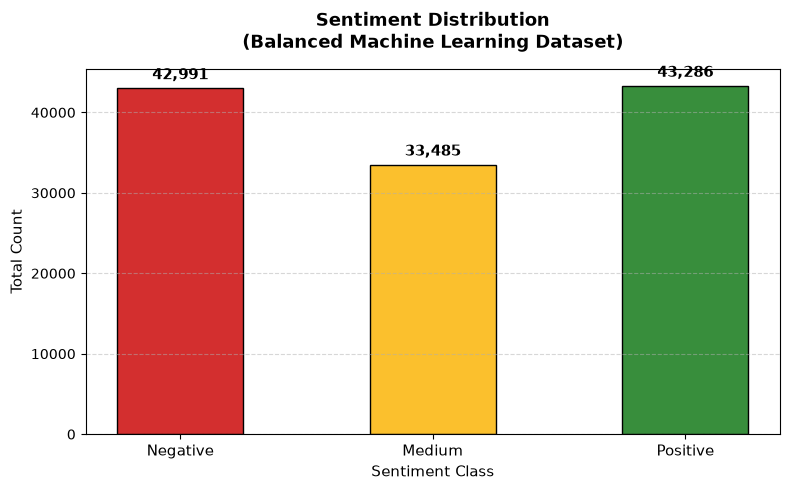

In [34]:
# ==========================================
# Plot the Sentiment Distribution Chart
# ==========================================
sentiment_counts = balanced_df['sentiment'].value_counts()

ordered_sentiments = ['negative', 'medium', 'positive']
sentiment_counts = sentiment_counts.reindex(ordered_sentiments)

plt.figure(figsize=(8, 5))
sentiment_colors = ['#d32f2f', '#fbc02d', '#388e3c']

bars = plt.bar(sentiment_counts.index, sentiment_counts.values, 
               color=sentiment_colors, edgecolor='black', width=0.5)

plt.title('Sentiment Distribution\n(Balanced Machine Learning Dataset)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Sentiment Class', fontsize=11)
plt.ylabel('Total Count', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.xticks(ticks=range(len(ordered_sentiments)), labels=[s.capitalize() for s in ordered_sentiments], fontsize=11)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height):,}', 
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 4),  
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
                 
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the balanced dataset
file_path = "data/balanced_shopping_reviews.csv"
print(f"Loading data from {file_path}...")

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: Could not find {file_path}. Run Cell 1 first!")
    exit()

# 2. Preprocessing (Using the NEW 'clean_content' column)
df['clean_content'] = df['clean_content'].fillna('') 

X = df['clean_content']  # The upgraded input feature
y = df['sentiment']      # The target variable

# 3. Train-Test Split (80% training, 20% testing)
print("Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Text Vectorization (Upgraded for N-Grams and Negations)
print("Vectorizing text data using TF-IDF (10,000 features, Bigrams enabled)...")
vectorizer = TfidfVectorizer(
    max_features=10000, 
    ngram_range=(1, 2),  # Reads 1-word and 2-word phrases
    min_df=5, 
    stop_words=None      # Keeps our critical 'not_X' words intact
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 5. Initialize the Models
# 5. Initialize the Models (Hyperparameter Tuning Extravaganza)
# 5. Initialize the Models (Strictly Logical & Multiclass-Safe)
models = {
    # --- LOGISTIC REGRESSION (Using 'lbfgs' and 'saga' solvers only) ---
    
    # 1. Baseline L2 (Default)
    "LR (Baseline L2)": LogisticRegression(max_iter=1000, random_state=42),
    
    # 2-4. Tuning 'C' with standard L2 penalty. 
    # (Low C = ignores noise/overfitting. High C = trusts the training data heavily)
    "LR (Strong Penalty, C=0.1)": LogisticRegression(C=0.1, max_iter=1000, random_state=42),
    "LR (Weak Penalty, C=10)": LogisticRegression(C=10.0, max_iter=1000, random_state=42),
    "LR (Very Weak Penalty, C=50)": LogisticRegression(C=50.0, max_iter=1000, random_state=42),
    
    # 5. Balanced Weights (Forces algorithm to care equally about all 3 classes)
    "LR (Balanced Weights)": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    
    # 6-8. L1 Penalty using 'saga' 
    # (L1 physically deletes useless words by pushing their weights to exactly 0.0)
    "LR (L1 Baseline, saga)": LogisticRegression(penalty='l1', solver='saga', max_iter=1000, random_state=42),
    "LR (L1 Strong Penalty, C=0.5)": LogisticRegression(penalty='l1', C=0.5, solver='saga', max_iter=1000, random_state=42),
    "LR (L1 Weak Penalty, C=5)": LogisticRegression(penalty='l1', C=5.0, solver='saga', max_iter=1000, random_state=42),
    
    # 9-10. ElasticNet (A hybrid of L1 and L2 using 'saga')
    "LR (ElasticNet, 50/50 split)": LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=1000, random_state=42),
    "LR (ElasticNet, 80% L1)": LogisticRegression(penalty='elasticnet', l1_ratio=0.8, solver='saga', max_iter=1000, random_state=42),


    # --- NAIVE BAYES (MNB) VARIATIONS ---
    
    # 1. Baseline (Alpha 1.0)
    "NB (Baseline, Alpha=1.0)": MultinomialNB(alpha=1.0),
    
    # 2-5. Tuning Alpha (Smoothing). 
    # (Low Alpha = assumes the dataset is a perfect representation of English. High = more cautious)
    "NB (Low Smooth, Alpha=0.5)": MultinomialNB(alpha=0.5),
    "NB (Very Low, Alpha=0.1)": MultinomialNB(alpha=0.1),
    "NB (Micro Smooth, Alpha=0.01)": MultinomialNB(alpha=0.01),
    "NB (High Smooth, Alpha=2.0)": MultinomialNB(alpha=2.0),
    "NB (Extreme Smooth, Alpha=5.0)": MultinomialNB(alpha=5.0),
    
    # 6-10. Fit_Prior = False 
    # (Forces the algorithm to mathematically assume classes are perfectly equal, ignoring slight data variances)
    "NB (Uniform, Alpha=1.0)": MultinomialNB(alpha=1.0, fit_prior=False),
    "NB (Uniform + Low Smooth, Alpha=0.5)": MultinomialNB(alpha=0.5, fit_prior=False),
    "NB (Uniform + Very Low, Alpha=0.1)": MultinomialNB(alpha=0.1, fit_prior=False),
    "NB (Uniform + High Smooth, Alpha=2.0)": MultinomialNB(alpha=2.0, fit_prior=False),
    "NB (Uniform + Extreme Smooth, Alpha=5.0)": MultinomialNB(alpha=5.0, fit_prior=False)
}
# 6. Training and Evaluation Loop
print("\n" + "="*60)
print("STARTING MODEL TRAINING & EVALUATION")
print("="*60)

results_summary = []

for model_name, model in models.items():
    print(f"-> Training {model_name}...")
    
    model.fit(X_train_vec, y_train)
    predictions = model.predict(X_test_vec)
    
    accuracy = accuracy_score(y_test, predictions)
    report = classification_report(y_test, predictions, output_dict=True)
    
    results_summary.append({
        "Model": model_name,
        "Accuracy": f"{accuracy * 100:.2f}%",
        "Negative F1": f"{report['negative']['f1-score']:.2f}",
        "Medium F1": f"{report['medium']['f1-score']:.2f}",
        "Positive F1": f"{report['positive']['f1-score']:.2f}"
    })

# 7. Print the Final Summary Table
print("\n" + "="*65)
print(" FINAL MODEL EVALUATION SUMMARY")
print("="*65)
summary_df = pd.DataFrame(results_summary)
print(summary_df.to_string(index=False, justify='center'))
print("="*65)
print("Pipeline Complete!")

Loading data from data/balanced_shopping_reviews.csv...
Splitting data into training and testing sets...
Vectorizing text data using TF-IDF (10,000 features, Bigrams enabled)...

STARTING MODEL TRAINING & EVALUATION
-> Training LR (Baseline L2)...
-> Training LR (Strong Penalty, C=0.1)...
-> Training LR (Weak Penalty, C=10)...
-> Training LR (Very Weak Penalty, C=50)...
-> Training LR (Balanced Weights)...
-> Training LR (L1 Baseline, saga)...


d:\torch-gpu\.venv_cuda\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\torch-gpu\.venv_cuda\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


-> Training LR (L1 Strong Penalty, C=0.5)...


d:\torch-gpu\.venv_cuda\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\torch-gpu\.venv_cuda\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


-> Training LR (L1 Weak Penalty, C=5)...


...

-> Training LR (ElasticNet, 50/50 split)...


d:\torch-gpu\.venv_cuda\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


-> Training LR (ElasticNet, 80% L1)...


d:\torch-gpu\.venv_cuda\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


-> Training NB (Baseline, Alpha=1.0)...
-> Training NB (Low Smooth, Alpha=0.5)...
-> Training NB (Very Low, Alpha=0.1)...
-> Training NB (Micro Smooth, Alpha=0.01)...
-> Training NB (High Smooth, Alpha=2.0)...
-> Training NB (Extreme Smooth, Alpha=5.0)...
-> Training NB (Uniform, Alpha=1.0)...
-> Training NB (Uniform + Low Smooth, Alpha=0.5)...
-> Training NB (Uniform + Very Low, Alpha=0.1)...
-> Training NB (Uniform + High Smooth, Alpha=2.0)...
-> Training NB (Uniform + Extreme Smooth, Alpha=5.0)...

 FINAL MODEL EVALUATION SUMMARY
                 Model                   Accuracy Negative F1 Medium F1 Positive F1
                        LR (Baseline L2)  66.78%      0.72       0.46       0.76   
              LR (Strong Penalty, C=0.1)  66.64%      0.73       0.43       0.76   
                 LR (Weak Penalty, C=10)  65.01%      0.70       0.44       0.75   
            LR (Very Weak Penalty, C=50)  64.08%      0.69       0.44       0.74   
                   LR (Balanced Weights) 